In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import json

In [6]:
file_path = '../../data/raw/data-new.json'
with open(file_path, "r") as file:
    data =json.load(file)

In [7]:
tree = pd.DataFrame(data['nodes'])

In [8]:
tree.head()

,id,name,thesis,school,country,year,subject,advisors,students
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]"
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]"
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[]
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[]
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[]


In [9]:
unique_subjects = tree["subject"].dropna().unique()

In [10]:
unique_subjects

array(['74—Mechanics of deformable solids', '62—Statistics',
       '68—Computer science', '08—General algebraic systems',
       '03—Mathematical logic and foundations',
       '06—Order, lattices, ordered algebraic structures',
       '65—Numerical analysis',
       '90—Operations research, mathematical programming',
       '44—Integral transforms, operational calculus',
       '97—Mathematics education',
       '82—Statistical mechanics, structure of matter',
       '76—Fluid mechanics', '54—General topology',
       '52—Convex and discrete geometry', '46—Functional analysis',
       '60—Probability theory and stochastic processes',
       '37—Dynamical systems and ergodic theory',
       '57—Manifolds and cell complexes',
       '34—Ordinary differential equations', '11—Number theory',
       '94—Information and communication, circuits',
       '20—Group theory and generalizations',
       '16—Associative rings and algebras',
       '30—Functions of a complex variable',
       '41—

In [11]:
sorted_subs = sorted(unique_subjects, key=lambda x: int(x.split("—")[0]))

In [12]:
subject_codes = [s.split("—")[0] for s in sorted_subs]
subject_names = [s.split("—")[1] for s in sorted_subs]
subjects = pd.DataFrame({
    "subject_Code": subject_codes,
    "subject_Name": subject_names
})

In [13]:
subjects

,subject_Code,subject_Name
0,00,General
1,01,History and biography
2,03,Mathematical logic and foundations
3,05,Combinatorics
4,06,"Order, lattices, ordered algebraic structures"
...,...,...
58,91,"Game theory, economics, social and behavioral ..."
59,92,Biology and other natural sciences
60,93,Systems theory; control
61,94,"Information and communication, circuits"


## Checking if there are subject areas with slight changes 

In [14]:
import re

def normalize_subject_name(name):
    if pd.isna(name):
        return None
    
    name = name.lower()
    name = name.replace("&", "and")
    name = re.sub(r"[^a-z0-9\s]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    
    return name

subjects["subject_Name_clean"] = subjects["subject_Name"].apply(normalize_subject_name)

In [15]:
subjects.head()

,subject_Code,subject_Name,subject_Name_clean
0,00,General,general
1,01,History and biography,history and biography
2,03,Mathematical logic and foundations,mathematical logic and foundations
3,05,Combinatorics,combinatorics
4,06,"Order, lattices, ordered algebraic structures",order lattices ordered algebraic structures


In [16]:
subjects[subjects.duplicated("subject_Name_clean", keep=False)].sort_values("subject_Name_clean")

,subject_Code,subject_Name,subject_Name_clean


In [17]:
!pip install rapidfuzz

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 27.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\Work\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [18]:
from rapidfuzz import fuzz

pairs = []

names = subjects[["subject_Code", "subject_Name", "subject_Name_clean"]].dropna()

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        row1 = names.iloc[i]
        row2 = names.iloc[j]
        
        score = fuzz.token_sort_ratio(
            row1["subject_Name_clean"],
            row2["subject_Name_clean"]
        )
        
        if score >= 80:
            pairs.append({
                "code_1": row1["subject_Code"],
                "name_1": row1["subject_Name"],
                "code_2": row2["subject_Code"],
                "name_2": row2["subject_Name"],
                "similarity": score
            })

similar_subjects = pd.DataFrame(pairs).sort_values("similarity", ascending=False)
similar_subjects

,code_1,name_1,code_2,name_2,similarity
1,16,Associative rings and algebras,17,Nonassociative rings and algebras,95.238095
3,34,Ordinary differential equations,35,Partial differential equations,85.245902
2,26,Real functions,33,Special functions,83.870968
0,13,Commutative rings and algebras,16,Associative rings and algebras,83.333333


In [19]:
tree["subject_code"] = tree["subject"].apply(lambda x: x.split("—")[0] if pd.notna(x) else None)
tree["subject_name"] = tree["subject"].apply(lambda x: x.split("—")[1] if pd.notna(x) else None)

In [20]:
tree.head(10)

,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]",74,Mechanics of deformable solids
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]",None,None
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[],None,None
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[],74,Mechanics of deformable solids
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[],None,None
5,6,William B. Stiles,Solutions of Clamped Plated Problems by Means ...,Iowa State University,UnitedStates,1945.0,None,[258],[],None,None
6,9,Henry David Block,Explicit Solutions of Certain Singular Integra...,Iowa State University,UnitedStates,1949.0,None,[281],"[23, 28, 71, 101996, 87826]",None,None
7,8,James W. Beach,Flow of Viscous Fluid between Slowing Rotating...,Iowa State University,UnitedStates,1948.0,None,[258],[],None,None
8,7,Carl Eric Langenhop,Properties of Kernels of Integral Equations Wh...,Iowa State University,UnitedStates,1948.0,None,[281],"[48, 104689, 38, 33, 3026, 39, 32, 35]",None,None
9,10,Frank E. Bortle,Analytical Study of Dynamic Loads on Elastical...,Iowa State University,UnitedStates,1949.0,None,[258],[],None,None


# Missing subjects

In [21]:
# make sure that the advisor and student lists are actual lists
def to_list(x):
    if isinstance(x, list):
        return x
    
    if pd.isna(x):
        return []
    
    if isinstance(x, str):
        if x in ["", "[]" , "None"]:
            return []
        return x.strip()
        
    return []

tree["advisors"] = tree["advisors"].apply(to_list)
tree["students"] = tree["students"].apply(to_list)

In [22]:
tree.head()


,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]",74,Mechanics of deformable solids
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]",None,None
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[],None,None
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[],74,Mechanics of deformable solids
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[],None,None


In [23]:
from collections import Counter 

In [24]:

def collect_subjects_from_neighbors(
    start_id,
    neighbor_dict,
    id_to_subject,
    max_depth=2
):   
    visited = set()
    queue = [(start_id, 0)]
    votes = Counter()
    
    while queue:
        current_id, depth = queue.pop(0)
        
        if depth >= max_depth:
            continue
        
        for neighbor_id in neighbor_dict.get(current_id, []):
            if neighbor_id in visited:
                continue
            
            visited.add(neighbor_id)
            
            subject = id_to_subject.get(neighbor_id)
            
            if subject is not None:
                # closer relatives get more weight
                weight = 1 / (depth + 1)
                votes[subject] += weight
            
            queue.append((neighbor_id, depth + 1))
    
    return votes

In [25]:
id_to_subject = dict(zip(tree["id"], tree["subject_code"]))
id_to_advisors = dict(zip(tree["id"], tree["advisors"]))
id_to_students = dict(zip(tree["id"], tree["students"]))

In [26]:
collect_subjects_from_neighbors(
    start_id=93643,
    neighbor_dict=id_to_students,
    id_to_subject=id_to_subject,
    max_depth=2
)

Counter({'94': 126.5, '68': 49.5, '93': 1.0, '20': 0.5})

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

In [28]:
known = tree[
    tree["subject_code"].notna() &
    tree["thesis"].notna()
].copy()


In [29]:
x_train, x_test, y_train, y_test = train_test_split(known["thesis"], known["subject_code"], test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_score


title_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced"
    ))
])

kf = KFold(n_splits=3, shuffle=True, random_state=42)

scores = cross_val_score(title_model, x_train, y_train, cv=kf, scoring='accuracy')
print(f"Mean Accuracy: {np.mean(scores):.4f}")

In [ ]:
logistic_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

random_forest_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

decision_tree_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", CalibratedClassifierCV(
        estimator=LinearSVC(
            class_weight="balanced",
            random_state=42,
            max_iter=5000
        ),
        cv=3
    ))
])

In [ ]:
cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [ ]:
from sklearn.model_selection import cross_validate


models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "SVM": svm_pipeline
}

results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        x_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        return_train_score=True,
        n_jobs=-1
    )
    
    results.append({
        "Model": model_name,
        "Mean Train Accuracy": scores["train_accuracy"].mean(),
        "Mean Test Accuracy": scores["test_accuracy"].mean(),
        "Std Test Accuracy": scores["test_accuracy"].std(),
        "Mean Train F1 Macro": scores["train_f1_macro"].mean(),
        "Mean Test F1 Macro": scores["test_f1_macro"].mean(),
        "Std Test F1 Macro": scores["test_f1_macro"].std()
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Mean Test Accuracy",
    ascending=False
)

results_df

,Model,Mean Train Accuracy,Mean Test Accuracy,Std Test Accuracy,Mean Train F1 Macro,Mean Test F1 Macro,Std Test F1 Macro
3,SVM,0.937189,0.612989,0.001085,0.942360,0.437752,0.002602
0,Logistic Regression,0.700706,0.567564,0.001143,0.689517,0.429059,0.001875
1,Random Forest,0.995925,0.559783,0.001720,0.988468,0.387293,0.001260
2,Decision Tree,0.995657,0.419793,0.001230,0.988108,0.285986,0.001152


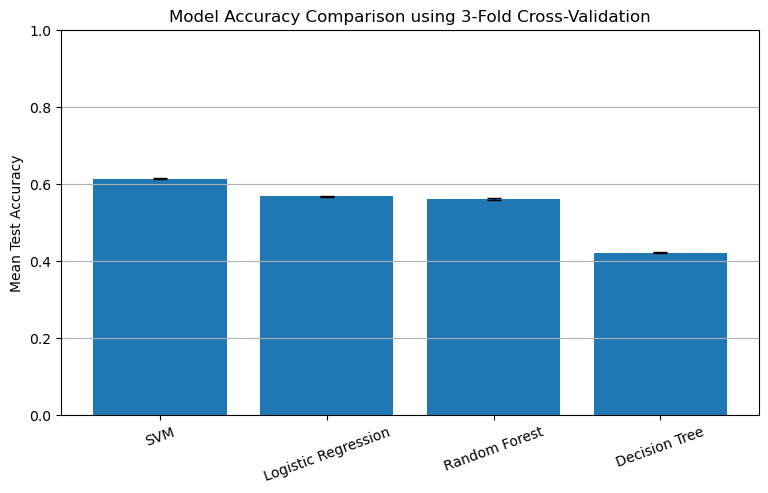

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Mean Test Accuracy"],
    yerr=results_df["Std Test Accuracy"],
    capsize=5
)

plt.ylabel("Mean Test Accuracy")
plt.title("Model Accuracy Comparison using 3-Fold Cross-Validation")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.show()

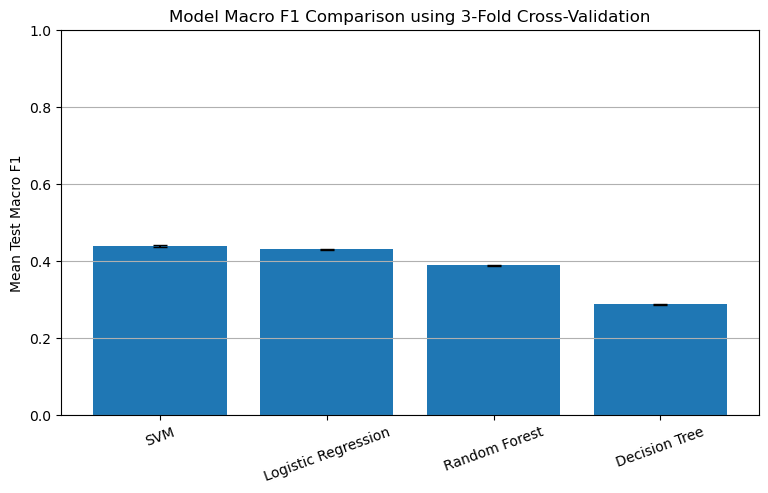

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Mean Test F1 Macro"],
    yerr=results_df["Std Test F1 Macro"],
    capsize=5
)

plt.ylabel("Mean Test Macro F1")
plt.title("Model Macro F1 Comparison using 3-Fold Cross-Validation")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.show()

In [ ]:
svm_pipeline.fit(x_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(class_weight='balanced',
                                                            max_iter=5000,
                                                            random_state=42)))])

In [ ]:
y_train_pred = svm_pipeline.predict(x_train)
y_test_pred = svm_pipeline.predict(x_test)

In [ ]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

In [ ]:
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9258
Testing Accuracy: 0.6596


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "clf__estimator__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    svm_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best C:", grid.best_params_)
print("Best macro F1:", grid.best_score_)

Best C: {'clf__estimator__C': 0.1}
Best macro F1: 0.45869641140223677


In [ ]:
best_svm = grid.best_estimator_

In [ ]:
best_svm.fit(x_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(C=0.1,
                                                            class_weight='balanced',
                                                            max_iter=5000,
                                                            random_state=42)))])

In [ ]:
y_train_pred = best_svm.predict(x_train)
y_test_pred = best_svm.predict(x_test)

In [ ]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

In [ ]:
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.7604
Testing Accuracy: 0.6362


In [ ]:
subject_classes = best_svm.named_steps["clf"].classes_

def thesis_subject_votes(thesis, top_k=5):
    if pd.isna(thesis) or thesis is None:
        return Counter()
    
    probs = best_svm.predict_proba([thesis])[0]
    
    top_indices = probs.argsort()[::-1][:top_k]
    
    votes = Counter()
    for i in top_indices:
        votes[subject_classes[i]] = probs[i]
    
    return votes

In [ ]:
def infer_subject_for_id(
    person_id,
    thesis,
    id_to_subject,
    id_to_advisors,
    id_to_students,
    max_depth=3,
    w_descendants=0.4,
    w_ancestors=0.2,
    w_thesis=0.4
):
    descendant_votes = collect_subjects_from_neighbors(
        person_id,
        id_to_students,
        id_to_subject,
        max_depth=max_depth
    )
    
    ancestor_votes = collect_subjects_from_neighbors(
        person_id,
        id_to_advisors,
        id_to_subject,
        max_depth=max_depth
    )
    
    thesis_votes = thesis_subject_votes(thesis)
    
    total_votes = Counter()
    
    for code, score in descendant_votes.items():
        total_votes[code] += w_descendants * score
    
    for code, score in ancestor_votes.items():
        total_votes[code] += w_ancestors * score
    
    for code, score in thesis_votes.items():
        total_votes[code] += w_thesis * score
    
    if not total_votes:
        return None, 0, {}
    
    best_code, best_score = total_votes.most_common(1)[0]
    
    total_score = sum(total_votes.values())
    confidence = best_score / total_score if total_score > 0 else 0
    
    return best_code, confidence, dict(total_votes)

In [ ]:
missing_mask = tree["subject_code"].isna()

results = tree.loc[missing_mask].apply(
    lambda row: infer_subject_for_id(
        person_id=row["id"],
        thesis=row["thesis"],
        id_to_subject=id_to_subject,
        id_to_advisors=id_to_advisors,
        id_to_students=id_to_students,
        max_depth=3
    ),
    axis=1
)

tree.loc[missing_mask, "predicted_subject_code"] = results.apply(lambda x: x[0])
tree.loc[missing_mask, "subject_prediction_confidence"] = results.apply(lambda x: x[1])
tree.loc[missing_mask, "subject_prediction_votes"] = results.apply(lambda x: x[2])

In [ ]:
tree.head()

,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence,subject_prediction_votes
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]",74,Mechanics of deformable solids,NaN,NaN,NaN
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]",None,None,81,0.507291,"{'81': 0.27499999999999997, '34': 0.1922412634..."
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[],None,None,91,0.394984,"{'85': 0.11, '91': 0.15196078228076626, '74': ..."
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[],74,Mechanics of deformable solids,NaN,NaN,NaN
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[],None,None,74,0.659632,"{'85': 0.11, '74': 0.25681168970594087, '62': ..."


In [ ]:
subjects.loc[subjects["subject_Code"] == "85"]

,subject_Code,subject_Name,subject_Name_clean
55,85,Astronomy and astrophysics,astronomy and astrophysics


In [ ]:
tree["final_subject_code"] = tree["subject_code"]

tree.loc[
    tree["final_subject_code"].isna(),
    "final_subject_code"
] = tree.loc[
    tree["final_subject_code"].isna(),
    "predicted_subject_code"
]

In [ ]:
tree = tree.merge(
    subjects,
    left_on="final_subject_code",
    right_on="subject_Code",
    how="left",
    suffixes=("", "_from_table")
)

In [ ]:
tree.tail()

,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence,subject_prediction_votes
338527,346122,Maria Heuss,Responsible Advice-Giving Systems: Fairness an...,Universiteit van Amsterdam,Netherlands,2025.0,68—Computer science,"[229284, 84191]",[],68,Computer science,NaN,NaN,NaN
338528,346123,Konstantin Burlachenko,Optimization Methods and Software for Federate...,King Abdullah University of Science and Techno...,SaudiArabia,2025.0,"90—Operations research, mathematical programming",[11470],[],90,"Operations research, mathematical programming",NaN,NaN,NaN
338529,346119,Jacob Stream Laxer,Packable Weak Poincare Inequality and Uniform ...,State University of New York at Stony Brook,UnitedStates,2025.0,28—Measure and integration,[18456],[],28,Measure and integration,NaN,NaN,NaN
338530,29316,Detlef Dürr,Wahrscheinlichste Wege von Diffusionsprozessen,Universität Münster,Germany,1978.0,60—Probability theory and stochastic processes,[300879],"[49602, 191494, 273114, 28892, 28895, 171502, ...",60,Probability theory and stochastic processes,NaN,NaN,NaN
338531,100043,Dmitri Loguinov,Adaptive Scalable Internet Streaming,City University of New York,UnitedStates,2002.0,68—Computer science,[99811],"[231378, 231380, 120300, 123732, 150492, 23137...",68,Computer science,NaN,NaN,NaN


In [ ]:
filled_tree = tree.copy()

threshold = 0.55

mask = (
    filled_tree["subject_code"].isna() &
    filled_tree["predicted_subject_code"].notna() &
    (filled_tree["subject_prediction_confidence"] > threshold)
)

# Fill subject_code from prediction
filled_tree.loc[mask, "subject_code"] = filled_tree.loc[mask, "predicted_subject_code"]

# Fill subject_name from subjects_df
code_to_name = dict(
    zip(subjects["subject_Code"], subjects["subject_Name"])
)

filled_tree.loc[mask, "subject_name"] = (
    filled_tree.loc[mask, "subject_code"].map(code_to_name)
)

filled_tree.head()

,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence,subject_prediction_votes
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]",74,Mechanics of deformable solids,NaN,NaN,NaN
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]",None,None,81,0.507291,"{'81': 0.27499999999999997, '34': 0.1922412634..."
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[],None,None,91,0.394984,"{'85': 0.11, '91': 0.15196078228076626, '74': ..."
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[],74,Mechanics of deformable solids,NaN,NaN,NaN
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[],74,Mechanics of deformable solids,74,0.659632,"{'85': 0.11, '74': 0.25681168970594087, '62': ..."


In [ ]:
print("Rows filled:", mask.sum())

Rows filled: 80195


In [ ]:
tree.to_csv('../../data/processed/tree_with_subjects.csv', index=False)

In [ ]:
data = pd.read_csv('../../data/processed/tree_with_subjects.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307399 non-null  object 
 3   school                         276167 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   subject                        202492 non-null  object 
 7   advisors                       338532 non-null  object 
 8   students                       338532 non-null  object 
 9   subject_code                   202492 non-null  float64
 10  subject_name                   202492 non-null  object 
 11  predicted_subject_code         129997 non-null  float64
 12  subject_prediction_confidence 

In [ ]:
known_new = filled_tree[
    filled_tree["subject_code"].notna() &
    filled_tree["thesis"].notna()
].copy()

In [ ]:
id_to_subject_new = dict(zip(filled_tree["id"], filled_tree["subject_code"]))
id_to_advisors_new = dict(zip(filled_tree["id"], filled_tree["advisors"]))
id_to_students_new = dict(zip(filled_tree["id"], filled_tree["students"]))

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(known_new["thesis"], known_new["subject_code"], test_size=0.2, random_state=42)

In [ ]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "SVM": svm_pipeline
}

results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        x_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        return_train_score=True,
        n_jobs=-1
    )
    
    results.append({
        "Model": model_name,
        "Mean Train Accuracy": scores["train_accuracy"].mean(),
        "Mean Test Accuracy": scores["test_accuracy"].mean(),
        "Std Test Accuracy": scores["test_accuracy"].std(),
        "Mean Train F1 Macro": scores["train_f1_macro"].mean(),
        "Mean Test F1 Macro": scores["test_f1_macro"].mean(),
        "Std Test F1 Macro": scores["test_f1_macro"].std()
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Mean Test Accuracy",
    ascending=False
)

results_df

c:\Users\osand\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
1 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\osand\anaconda3\Lib\site-packages\joblib\_utils.py", line 72, in __call__
    return self.func(**kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\osand\anaconda3\Lib\site-packages\joblib\parallel.py", line 598, in __call__
    return [func(*args, **kwargs)
            ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\osand\anaconda3\Lib\site-packages\sklearn\utils\parallel.py", line 136, in __call__
    r

,Model,Mean Train Accuracy,Mean Test Accuracy,Std Test Accuracy,Mean Train F1 Macro,Mean Test F1 Macro,Std Test F1 Macro
3,SVM,0.928059,0.675056,0.001108,0.937610,0.517321,0.000297
0,Logistic Regression,0.717231,0.603110,0.001007,0.701084,0.473383,0.001751
2,Decision Tree,0.996047,0.458625,0.002914,0.990399,0.338309,0.001976
1,Random Forest,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
param_grid = {
    "clf__estimator__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    svm_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best C:", grid.best_params_)
print("Best macro F1:", grid.best_score_)

KeyboardInterrupt: 

In [ ]:
best_svm_new = grid.best_estimator_

In [ ]:
best_svm_new.fit(x_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(C=1,
                                                            class_weight='balanced',
                                                            max_iter=5000,
                                                            random_state=42)))])

In [ ]:
y_train_pred = best_svm_new.predict(x_train)
y_test_pred = best_svm_new.predict(x_test)

In [ ]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

In [ ]:
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9247
Testing Accuracy: 0.6915


In [ ]:
macro_f1 = f1_score(y_test, y_test_pred, average="macro")
print(f"Testing Macro F1 Score: {macro_f1:.4f}")

Testing Macro F1 Score: 0.5342


In [ ]:
logistic_pipeline.fit(x_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [ ]:
y_train_pred = logistic_pipeline.predict(x_train)
y_test_pred = logistic_pipeline.predict(x_test)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.7184
Testing Accuracy: 0.6192


In [ ]:
macro_f1 = f1_score(y_test, y_test_pred, average="macro")
print(f"Testing Macro F1 Score: {macro_f1:.4f}")

Testing Macro F1 Score: 0.4868


In [ ]:
subject_classes = logistic_pipeline.named_steps["clf"].classes_

def thesis_subject_votes(thesis, top_k=5):
    if pd.isna(thesis) or thesis is None:
        return Counter()
    
    probs = logistic_pipeline.predict_proba([thesis])[0]
    
    top_indices = probs.argsort()[::-1][:top_k]
    
    votes = Counter()
    for i in top_indices:
        votes[subject_classes[i]] = probs[i]
    
    return votes

In [ ]:
missing_mask = filled_tree["subject_code"].isna()

results = filled_tree.loc[missing_mask].apply(
    lambda row: infer_subject_for_id(
        person_id=row["id"],
        thesis=row["thesis"],
        id_to_subject=id_to_subject_new,
        id_to_advisors=id_to_advisors_new,
        id_to_students=id_to_students_new,
        max_depth=3
    ),
    axis=1
)

filled_tree.loc[missing_mask, "predicted_subject_code"] = results.apply(lambda x: x[0])
filled_tree.loc[missing_mask, "subject_prediction_confidence"] = results.apply(lambda x: x[1])
filled_tree.loc[missing_mask, "subject_prediction_votes"] = results.apply(lambda x: x[2])

In [ ]:
filled_tree.head()

,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence,subject_prediction_votes
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]",74,Mechanics of deformable solids,NaN,NaN,NaN
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]",None,None,81,0.546882,"{'81': 0.3666666666666667, '34': 0.21957184048..."
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[],None,None,85,0.314931,"{'85': 0.06666666666666667, '74': 0.0566787016..."
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[],74,Mechanics of deformable solids,NaN,NaN,NaN
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[],74,Mechanics of deformable solids,74,0.659632,"{'85': 0.11, '74': 0.25681168970594087, '62': ..."


In [ ]:
subjects.loc[subjects["subject_Code"] == "85"]

,subject_Code,subject_Name,subject_Name_clean
55,85,Astronomy and astrophysics,astronomy and astrophysics


In [ ]:
filled_tree_new = filled_tree.copy()

threshold = 0.55

mask = (
    filled_tree_new["subject_code"].isna() &
    filled_tree_new["predicted_subject_code"].notna() &
    (filled_tree_new["subject_prediction_confidence"] > threshold)
)

# Fill subject_code from prediction
filled_tree_new.loc[mask, "subject_code"] = filled_tree_new.loc[mask, "predicted_subject_code"]

# Fill subject_name from subjects_df
code_to_name = dict(
    zip(subjects["subject_Code"], subjects["subject_Name"])
)

filled_tree_new.loc[mask, "subject_name"] = (
    filled_tree_new.loc[mask, "subject_code"].map(code_to_name)
)

filled_tree_new.head()

,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence,subject_prediction_votes
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]",74,Mechanics of deformable solids,NaN,NaN,NaN
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]",None,None,81,0.546882,"{'81': 0.3666666666666667, '34': 0.21957184048..."
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[],None,None,85,0.314931,"{'85': 0.06666666666666667, '74': 0.0566787016..."
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[],74,Mechanics of deformable solids,NaN,NaN,NaN
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[],74,Mechanics of deformable solids,74,0.659632,"{'85': 0.11, '74': 0.25681168970594087, '62': ..."


In [ ]:
print("Rows filled:", mask.sum())

Rows filled: 19419


In [ ]:
filled_tree_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307400 non-null  object 
 3   school                         281806 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   subject                        202492 non-null  object 
 7   advisors                       338532 non-null  object 
 8   students                       338532 non-null  object 
 9   subject_code                   302106 non-null  object 
 10  subject_name                   302106 non-null  object 
 11  predicted_subject_code         133502 non-null  object 
 12  subject_prediction_confidence 

In [ ]:
saving_file = pd.DataFrame()
saving_file["id"] = filled_tree_new["id"]
saving_file["name"] = filled_tree_new["name"]
saving_file["thesis"] = filled_tree_new["thesis"]   
saving_file["school"] = filled_tree_new["school"]
saving_file["country"] = filled_tree_new["country"]
saving_file["year"] = filled_tree_new["year"]
saving_file["advisors"] = filled_tree_new["advisors"]
saving_file["students"] = filled_tree_new["students"]
saving_file["subject_code"] = filled_tree_new["subject_code"]   
saving_file["subject_name"] = filled_tree_new["subject_name"]
saving_file["predicted_subject_code"] = filled_tree_new["predicted_subject_code"]
saving_file["subject_prediction_confidence"] = filled_tree_new["subject_prediction_confidence"]

In [ ]:
saving_file.head()

,id,name,thesis,school,country,year,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,[258],"[11, 28, 31]",74,Mechanics of deformable solids,NaN,NaN
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,[239],"[19930, 19939]",None,None,81,0.546882
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,[258],[],None,None,85,0.314931
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,[258],[],74,Mechanics of deformable solids,NaN,NaN
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,[258],[],74,Mechanics of deformable solids,74,0.659632


In [ ]:
saving_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307400 non-null  object 
 3   school                         281806 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   advisors                       338532 non-null  object 
 7   students                       338532 non-null  object 
 8   subject_code                   302106 non-null  object 
 9   subject_name                   302106 non-null  object 
 10  predicted_subject_code         133502 non-null  object 
 11  subject_prediction_confidence  136040 non-null  float64
dtypes: float64(2), int64(1), objec

In [ ]:
saving_file.to_csv('../../data/processed/dataset_filled_subjects_new.csv', index=False)

In [ ]:
saving_file.loc[saving_file["subject_code"].isna() & (saving_file.year >=2000)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 7162 entries, 1262 to 338283
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             7162 non-null   int64  
 1   name                           7162 non-null   object 
 2   thesis                         6665 non-null   object 
 3   school                         7162 non-null   object 
 4   country                        6984 non-null   object 
 5   year                           7162 non-null   float64
 6   advisors                       7162 non-null   object 
 7   students                       7162 non-null   object 
 8   subject_code                   0 non-null      object 
 9   subject_name                   0 non-null      object 
 10  predicted_subject_code         6844 non-null   object 
 11  subject_prediction_confidence  7162 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage:

In [ ]:
subjects.loc[subjects["subject_Code"] == "86"]

,subject_Code,subject_Name,subject_Name_clean
56,86,Geophysics,geophysics
